# Tratamento e Análise Exploratória de Dados: **2024 World Happiness Report**

Escolhi um dataset que fornece informações relacionadas ao nível de felicidade de países no ano de 2024, baseado nas pesquisas feitas pelo The World Happiness Report.

[Link do dataset](https://www.kaggle.com/datasets/jainaru/world-happiness-report-2024-yearly-updated/data?select=World-happiness-report-2024.csv)

Explicação breve de cada coluna do dataset:
1. **Country name (Nome do país):** Nome do país.

2. **Regional indicator (Indicador regional):** Região à qual o país pertence.

3. **Ladder score (Índice de felicidade):** A pontuação de felicidade de cada país, baseada nas respostas à pergunta da Escala de Cantril, que pede aos entrevistados que pensem em uma escada na qual a melhor vida possível para eles seria um 10 e a pior vida possível seria um 0.

4. **Upper whisker (Limite superior):** Limite superior da pontuação de felicidade.

5. **Lower whisker (Limite inferior):** Limite inferior da pontuação de felicidade.

6. **Log GDP per capita (Log do PIB per capita):** O logaritmo natural do PIB per capita do país, ajustado pela Paridade do Poder de Compra (PPC) para levar em conta as diferenças no custo de vida entre os países.

7. **Social support (Apoio social):** A média nacional de respostas binárias (0 ou 1, representando Não/Sim) à pergunta sobre ter parentes ou amigos com quem contar em momentos de dificuldade.

8. **Healthy life expectancy (Expectativa de vida saudável):** O número médio de anos que um recém-nascido viveria com boa saúde, com base nas taxas de mortalidade e na expectativa de vida em diferentes idades.

9. **Freedom to make life choices (Liberdade para fazer escolhas de vida):** A média nacional de respostas à pergunta sobre a satisfação com a liberdade para escolher o que fazer com a própria vida.

10. **Generosity (Generosidade):** O resíduo da regressão da média nacional de respostas à pergunta sobre doar dinheiro para caridade em relação ao PIB per capita.

11. **Perceptions of corruption (Percepção de corrupção):** A média nacional das respostas da pesquisa a perguntas sobre a extensão percebida da corrupção no governo e nas empresas.


# Motivação da Exploração

O índice varia conforme o continente?

A liberdade de escolha possui relação com o score final?

# Importando Bibliotecas

In [23]:
#importando bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Coleta dos dados

In [24]:
#coletando os dados
df = pd.read_csv('/content/World-happiness-report-2024.csv')

In [25]:
#preview do dataset - 5 primeiras linhas
df.head()

,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


In [26]:
#infos do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  143 non-null    object 
 1   Regional indicator            143 non-null    object 
 2   Ladder score                  143 non-null    float64
 3   upperwhisker                  143 non-null    float64
 4   lowerwhisker                  143 non-null    float64
 5   Log GDP per capita            140 non-null    float64
 6   Social support                140 non-null    float64
 7   Healthy life expectancy       140 non-null    float64
 8   Freedom to make life choices  140 non-null    float64
 9   Generosity                    140 non-null    float64
 10  Perceptions of corruption     140 non-null    float64
 11  Dystopia + residual           140 non-null    float64
dtypes: float64(10), object(2)
memory usage: 13.5+ KB


In [27]:
#resumo estatístico do df com describe
df.describe()

,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
count,143.000000,143.000000,143.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,5.527580,5.641175,5.413972,1.378807,1.134329,0.520886,0.620621,0.146271,0.154121,1.575914
std,1.170717,1.155008,1.187133,0.425098,0.333317,0.164923,0.162492,0.073441,0.126238,0.537459
min,1.721000,1.775000,1.667000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.073000
25%,4.726000,4.845500,4.606000,1.077750,0.921750,0.398000,0.527500,0.091000,0.068750,1.308250
50%,5.785000,5.895000,5.674000,1.431500,1.237500,0.549500,0.641000,0.136500,0.120500,1.644500
75%,6.416000,6.507500,6.319000,1.741500,1.383250,0.648500,0.736000,0.192500,0.193750,1.881750
max,7.741000,7.815000,7.667000,2.141000,1.617000,0.857000,0.863000,0.401000,0.575000,2.998000


In [28]:
#exibição das colunas presentes no DF
df.columns

Index(['Country name', 'Regional indicator', 'Ladder score', 'upperwhisker',
       'lowerwhisker', 'Log GDP per capita', 'Social support',
       'Healthy life expectancy', 'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Dystopia + residual'],
      dtype='object')

In [29]:
#verificando se possuem valores nulos em cada coluna
df.isnull().sum()

,0
Country name,0
Regional indicator,0
Ladder score,0
upperwhisker,0
lowerwhisker,0
Log GDP per capita,3
Social support,3
Healthy life expectancy,3
Freedom to make life choices,3
Generosity,3


In [30]:
#verificando se possuem linhas iguais
df.duplicated().sum()

np.int64(0)

# **Visualização Gráfica**

Visualização gráfica das duas colunas que motivam a segunda pergunta da análise, sendo elas:

*   Ladder score
*   Freedom to make life choices

### Freedom to make life choices

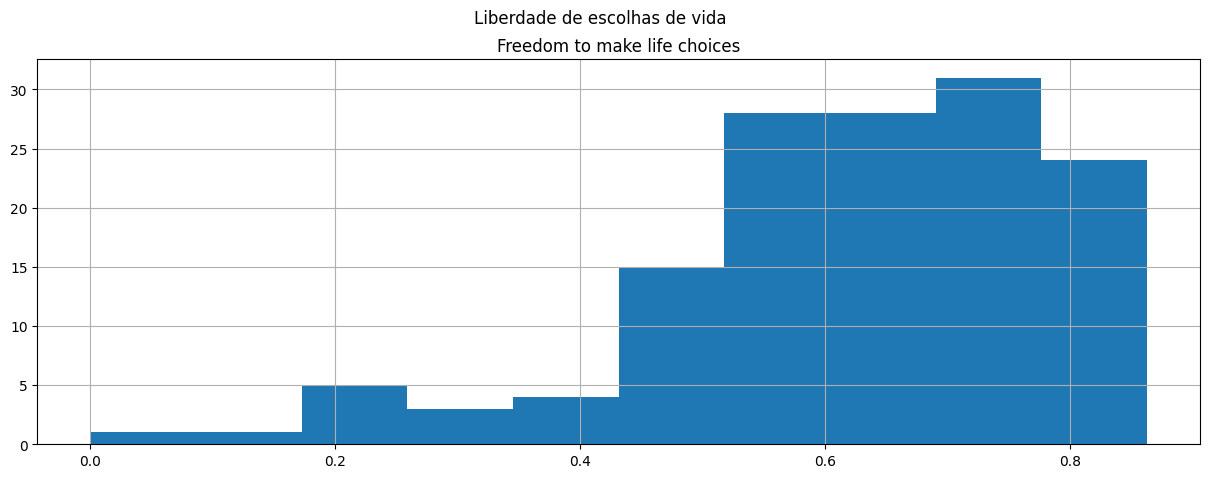

In [31]:
#histograma que exibe a variável
df[['Freedom to make life choices']].hist(bins=10,figsize = (15,5))
plt.suptitle('Liberdade de escolhas de vida')
plt.show()

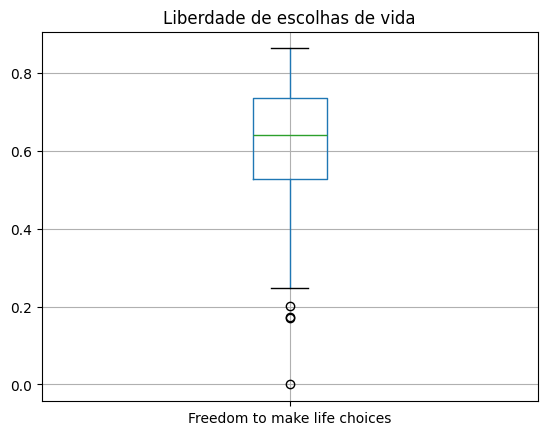

In [32]:
#boxplot na coluna
df.boxplot(column='Freedom to make life choices')

plt.title('Liberdade de escolhas de vida')
plt.show()

### Ladder Score



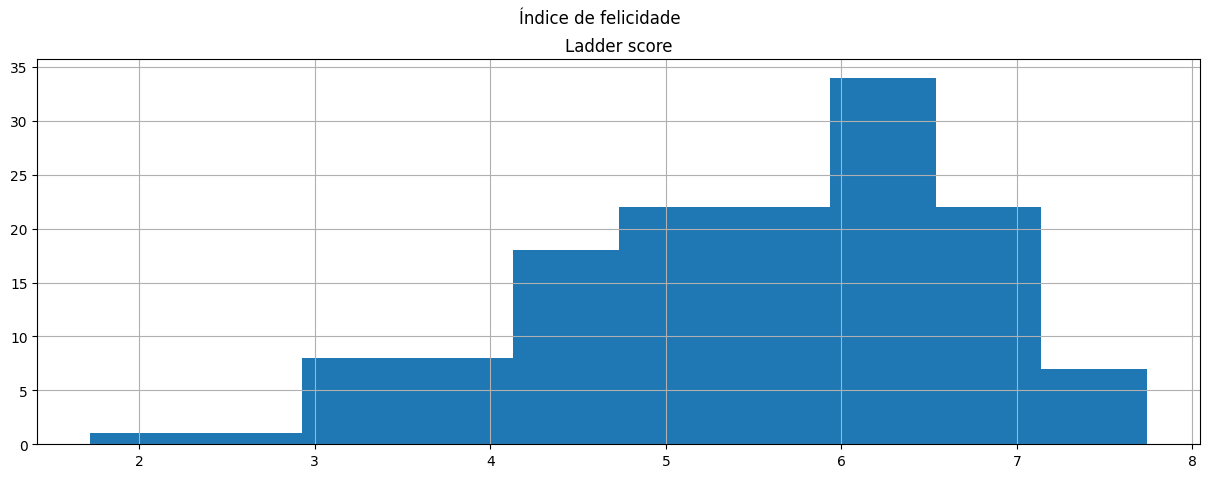

In [33]:
#histograma da variável
df[['Ladder score']].hist(bins=10,figsize = (15,5))
plt.suptitle('Índice de felicidade')
plt.show()

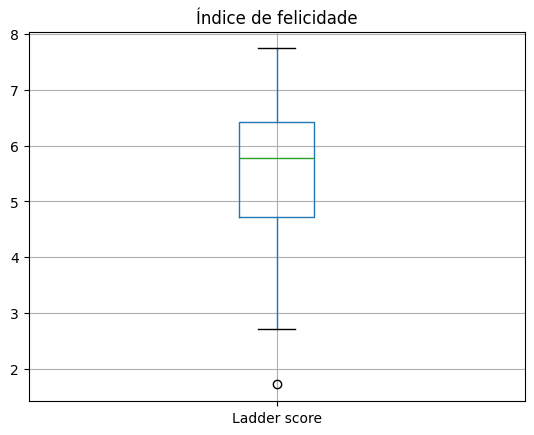

In [34]:
#boxplot da coluna
df.boxplot(column='Ladder score')

plt.title('Índice de felicidade')
plt.show()

# Tratamento e Limpeza

*   Tratar valores nulos em colunas
*   Renomear colunas
*   Criar um rank



### *Tratamento de valores nulos*

Como demonstrado na coletados dados, algumas colunas possuem valores nulos, sendo que uma dessas colunas é a "Freedom to make life choices", que motiva a primeira pergunta da análise.

Portanto, esses valores nulos devem ser tratados.

Como são poucos valores nulos, 3 de 143, vou remover as 3 linhas nulas.

In [35]:
#checando novamente valores nulos nas colunas
df.isnull().sum()

,0
Country name,0
Regional indicator,0
Ladder score,0
upperwhisker,0
lowerwhisker,0
Log GDP per capita,3
Social support,3
Healthy life expectancy,3
Freedom to make life choices,3
Generosity,3


In [36]:
#removendo (dropando) as linhas na qual a coluna 'Freedom to make life choices' possui valores nulos
df = df.dropna(subset=['Freedom to make life choices'])

In [37]:
#exibindo valores nulos em colunas
df.isnull().sum()

,0
Country name,0
Regional indicator,0
Ladder score,0
upperwhisker,0
lowerwhisker,0
Log GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0


### *Renomeação de Colunas*

Regional indicator para **Region**

Ladder Score para **Happiness Score**

In [38]:
df = df.rename(columns={'Regional indicator' : 'Region','Ladder score' : 'Happiness Score'})
df.head()

,Country name,Region,Happiness Score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


### *Criação de um Rank*

Rank em ordem crescente de acordo com o índice de felicidade

In [39]:
df.insert(0,'Rank',df['Happiness Score'].rank(ascending=False).astype(int))
df.head()

,Rank,Country name,Region,Happiness Score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,1,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,2,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,3,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,4,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,5,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


# **EDA - Análise Exploratória:**

Levando em conta as perguntas que motivam a análise:

*   O índice varia conforme o continente?
*   A liberdade de escolha possui relação com o score final?

Farei uma partição do dataframe original para que o novo esteja direcionado para a análise das perguntas acima.

As colunas restantes serão:

*   Rank
*   Country name
*   Happiness Score
*   Freedom to make life choices

In [40]:
#Gerando o dataframe com as colunas que serão utilizadas
df_final = df[['Rank', 'Country name', 'Happiness Score', 'Freedom to make life choices']]
df_final.head()

,Rank,Country name,Happiness Score,Freedom to make life choices
0,1,Finland,7.741,0.859
1,2,Denmark,7.583,0.823
2,3,Iceland,7.525,0.819
3,4,Sweden,7.344,0.838
4,5,Israel,7.341,0.641


## O índice varia conforme o continente?

Para responder essa pergunta, terei de criar uma nova coluna para o dataframe, pois a coluna 'Region' exibe uma espécie de "subregião" do continente da qual o país faz parte.

Para contornar esse obstáculo, encontrei a biblioteca 'country_converter', que fornece o continente de qual o país faz parte com base no seu nome.

In [ ]:
#instalação e importação da lib country_converter
!pip install country_converter --upgrade

In [42]:
import country_converter as coco

In [ ]:
cc = coco.CountryConverter()

#criando a coluna 'Continent', com base no continente do país da coluna 'Country name', utilizando o método convert()
df_final['Continent'] = coco.convert(names= df_final['Country name'] , to = 'continent')

In [44]:
#df atualizado com o nome dos continentes de cada país:
df_final.head()

,Rank,Country name,Happiness Score,Freedom to make life choices,Continent
0,1,Finland,7.741,0.859,Europe
1,2,Denmark,7.583,0.823,Europe
2,3,Iceland,7.525,0.819,Europe
3,4,Sweden,7.344,0.838,Europe
4,5,Israel,7.341,0.641,Asia


Partindo pra análise, irei comparar os continentes pela sua média e mediana da coluna **'Happiness score'**.

In [45]:
#mostrando a quantidade de países presentes em cada continente
df_final['Continent'].value_counts()

,count
Continent,
Africa,40
Europe,39
Asia,38
America,21
Oceania,2


In [46]:
#usando groupby para mostrar a média de cada continente
print('Média pura do índice de felicidade dos países de cada continente: ')

df_final.groupby('Continent')['Happiness Score'].mean()

Média pura do índice de felicidade dos países de cada continente: 


,Happiness Score
Continent,
Africa,4.399075
America,6.207095
Asia,5.310053
Europe,6.465256
Oceania,7.043000


In [47]:
#usando groupby para mostrar a mediana de cada continente
print('Mediana do índice de felicidade nos países dos continentes: ')
df_final.groupby('Continent')['Happiness Score'].median()

Mediana do índice de felicidade nos países dos continentes: 


,Happiness Score
Continent,
Africa,4.4460
America,6.2720
Asia,5.5115
Europe,6.4480
Oceania,7.0430


## Resultado

De fato, o índice varia conforme o continente.

É necessário reparar que, embora a Oceania esteja com a melhor média e mediana, a mesma possui apenas 2 integrantes no ranking.

## A liberdade de escolha está relacionada com o score final?

Para verificar a correlação entre as duas variáveis, farei a associação por meio do **Coeficiente de Pearson** entre as colunas "Happiness score" e "Freedom to make life choices".

Para tal, vou usar o método .corr() do pandas, que retorna o coeficiente, no range entre -1 e 1.

Se a correlação for positiva, as variáveis possuem uma relação direta..

Se o coeficiente for negativo, as variáveis possuem uma relação inversamente proporcional, no qual a medida que uma decresce outra cresce, e vice-versa.

Se o coeficiente for nulo, não há relação entre o crescimento ou decrescimento de ambas.

In [50]:
#verificando correlação com o método .corr()
correlacao = df_final['Happiness Score'].corr(df_final['Freedom to make life choices'])
print(correlacao)

0.6444511472915279


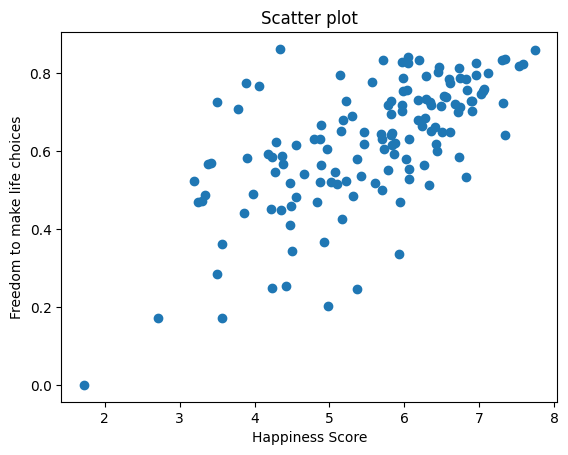

In [52]:
#scatter plot para visualizar essa relação
plt.scatter(df_final['Happiness Score'],df_final['Freedom to make life choices'])
plt.xlabel('Happiness Score')
plt.ylabel('Freedom to make life choices')
plt.title('Scatter plot')
plt.show()

## Resultado

O resultado entre a correlação é positivo (0.64), o que demonstra a relação direta entre as duas variáveis.